## Install & Imports

In [2]:
!pip install ydata-profiling
!pip install xgboost lightgbm imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Shallow Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Ensemble Models
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# SMOTE
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Read Data

In [5]:
df=pd.read_csv (r'synthetic_fraud_dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

# Checking Null Values

In [7]:
df.isna().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,0
Transaction_Type,0
Timestamp,0
Account_Balance,0
Device_Type,0
Location,0
Merchant_Category,0
IP_Address_Flag,0


# Visualization

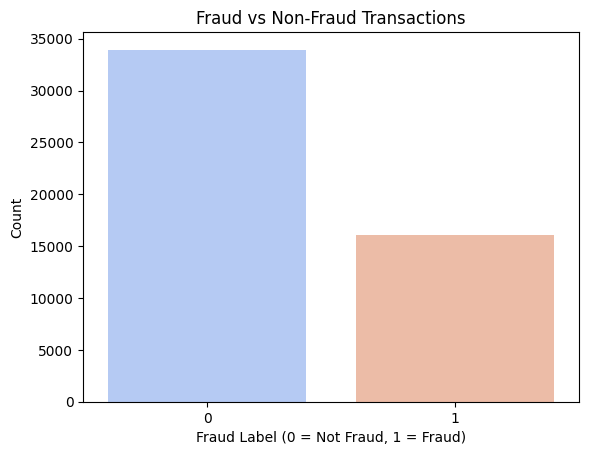

In [8]:
sns.countplot(x=df['Fraud_Label'], palette='coolwarm')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

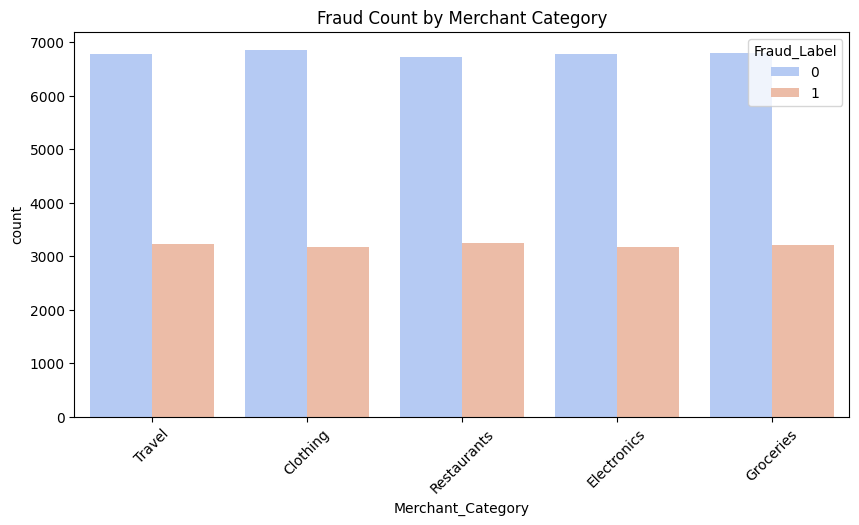

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='Merchant_Category', hue='Fraud_Label', data=df, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Fraud Count by Merchant Category")
plt.show()

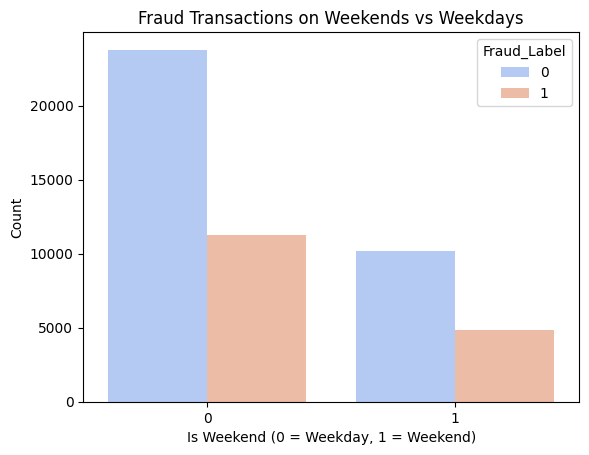

In [10]:
sns.countplot(x=df['Is_Weekend'], hue=df['Fraud_Label'], palette='coolwarm')
plt.title("Fraud Transactions on Weekends vs Weekdays")
plt.xlabel("Is Weekend (0 = Weekday, 1 = Weekend)")
plt.ylabel("Count")
plt.show()

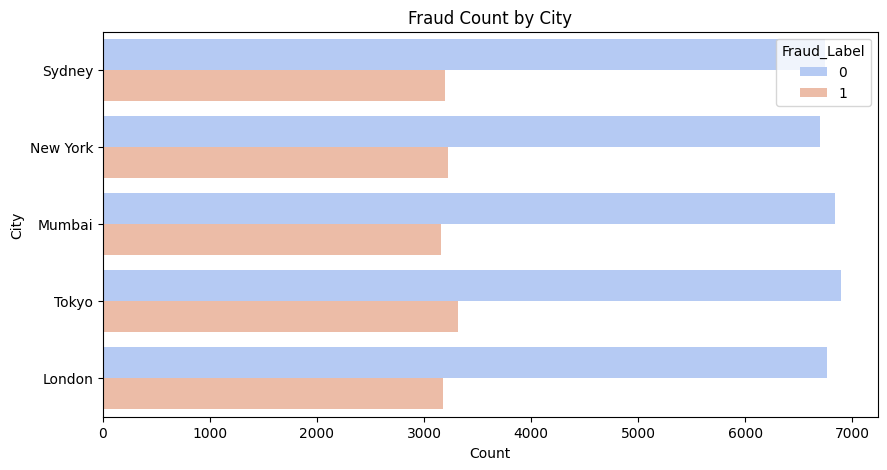

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(y=df['Location'], hue=df['Fraud_Label'], palette='coolwarm')
plt.title("Fraud Count by City")
plt.xlabel("Count")
plt.ylabel("City")
plt.show()

# Splitting Data

In [12]:
x=df.drop(['Transaction_ID','User_ID','Fraud_Label'],axis=1)
y=df['Fraud_Label']

# Encoding Categorical Data

In [13]:
le=LabelEncoder()
for cols in x.select_dtypes('object').columns:
    x[cols]=le.fit_transform(x[cols])

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

# Apply SMOTE

In [15]:
sm = SMOTE(random_state=42)
x_train, y_train = sm.fit_resample(x_train, y_train)

print("After SMOTE Oversampling:")
print("x_train shape:", x_train.shape)
print("y_train distribution:\n", pd.Series(y_train).value_counts())

After SMOTE Oversampling:
x_train shape: (54210, 18)
y_train distribution:
 Fraud_Label
0    27105
1    27105
Name: count, dtype: int64


# Scaling Numerical Data

In [16]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Evaluating All Models

In [17]:
shallow_models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB()
}

ensemble_models = {
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier()
}

all_models = {**shallow_models, **ensemble_models}

In [18]:
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}
train_losses = []
test_losses = []

for name, model in all_models.items():
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, average='weighted')
    rec = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')

    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['Precision'].append(prec)
    results['Recall'].append(rec)
    results['F1-Score'].append(f1)

    train_loss = 1 - accuracy_score(y_train, y_train_pred)
    test_loss = 1 - accuracy_score(y_test, y_test_pred)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

results_df = pd.DataFrame(results)
print(results_df)

[LightGBM] [Info] Number of positive: 27105, number of negative: 27105
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1831
[LightGBM] [Info] Number of data points in the train set: 54210, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.7941   0.808546  0.7941  0.798322
1                  KNN    0.7747   0.795099  0.7747  0.780205
2        Decision Tree    0.9483   0.955546  0.9483  0.949231
3                  SVM    0.9441   0.949837  0.9441  0.944987
4          Naive Bayes    0.7378   0.780722  0.7378  0.746385
5        Random Forest    0.9834   0.984226  0.9834  0.983510
6             AdaBoost    0.9759   0.977602  0.9759  0.976125
7

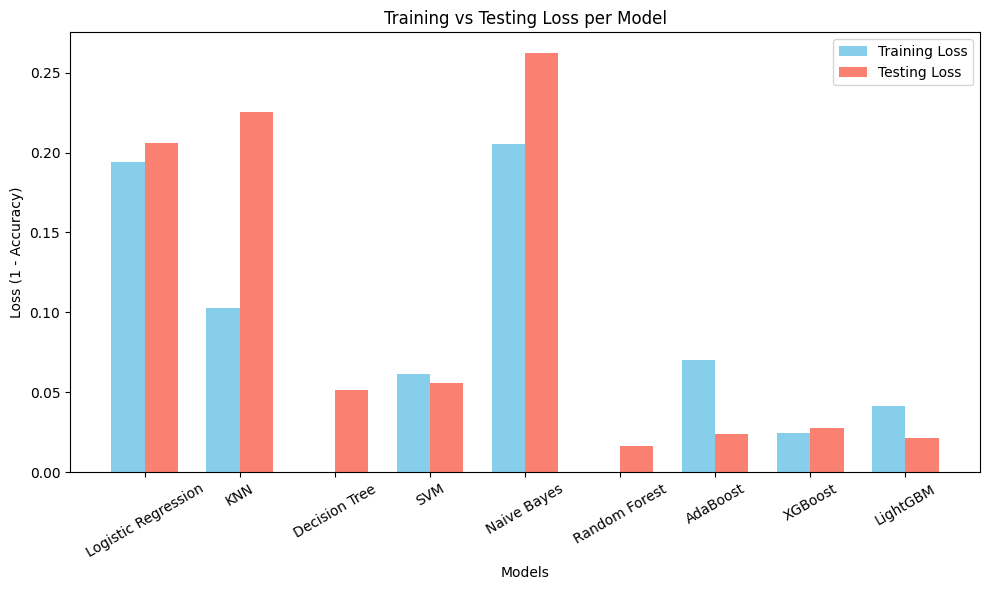

In [19]:
plt.figure(figsize=(10,6))
bar_width = 0.35
index = np.arange(len(all_models))

plt.bar(index, train_losses, bar_width, label='Training Loss', color='skyblue')
plt.bar(index + bar_width, test_losses, bar_width, label='Testing Loss', color='salmon')

plt.xlabel('Models')
plt.ylabel('Loss (1 - Accuracy)')
plt.title('Training vs Testing Loss per Model')
plt.xticks(index + bar_width/2, list(all_models.keys()), rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# Grid Search for NaiveBayes

In [20]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()

param_grid = {
    'alpha': [0.1, 0.5, 1.0, 5.0, 10.0],
    'binarize': [0.0, 0.5, 1.0, 1.5, 2.0]
}

grid_search = GridSearchCV(estimator=bnb, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


best_nb = grid_search.best_estimator_
y_pred = best_nb.predict(x_test)


print(classification_report(y_test, y_pred))

Best parameters found:  {'alpha': 0.1, 'binarize': 1.0}
Best Accuracy: 0.8935620734181885
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6828
           1       0.95      1.00      0.97      3172

    accuracy                           0.98     10000
   macro avg       0.98      0.99      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Confusion Matrix

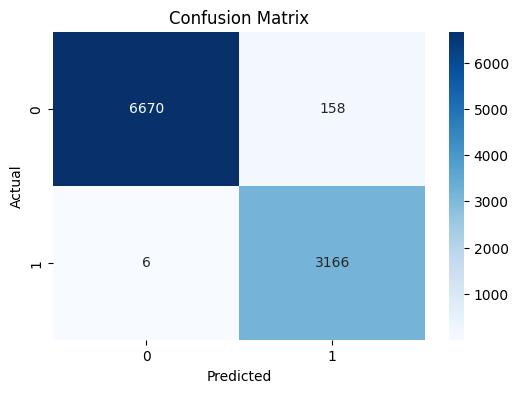

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()